In [13]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


class AlgoritmoGenetico:
    def __init__(self, tamanho_populacao, taxa_mutacao, tamanho_elitismo=2):
        self.tamanho_populacao = tamanho_populacao
        self.taxa_mutacao = taxa_mutacao
        self.tamanho_elitismo = tamanho_elitismo
        self.populacao = []

    # Metodos que DEVEM ser sobrescritos pelas classes filhas
    def gerar_individuo(self):
        raise NotImplementedError("Os alunos precisam definir como e o cromossomo!")

    def calcular_fitness(self, individuo):
        raise NotImplementedError("Os alunos precisam definir a funcao de aptidao!")

    def crossover(self, pai1, pai2):
        raise NotImplementedError("Os alunos precisam definir como os pais se reproduzem!")

    def mutacao(self, individuo):
        raise NotImplementedError("Os alunos precisam definir a mutacao para gerar diversidade!")

    def inicializar_populacao(self):
        self.populacao = [self.gerar_individuo() for _ in range(self.tamanho_populacao)]

    def _copiar_individuo(self, individuo):
        if isinstance(individuo, np.ndarray):
            return individuo.copy()
        if isinstance(individuo, list):
            return individuo.copy()
        return individuo

    def selecao_roleta(self, fitness_populacao):
        fitness_populacao = np.array(fitness_populacao, dtype=float)
        menor = float(np.min(fitness_populacao))
        if menor < 0:
            fitness_populacao = fitness_populacao - menor + 1e-9

        soma_fitness = float(np.sum(fitness_populacao))
        if soma_fitness <= 0:
            return self._copiar_individuo(random.choice(self.populacao))

        probabilidades = fitness_populacao / soma_fitness
        indice_escolhido = np.random.choice(len(self.populacao), p=probabilidades)
        return self._copiar_individuo(self.populacao[indice_escolhido])

    def evoluir(self, max_geracoes, objetivo_fitness=None, paciencia=None, verbose=True):
        self.inicializar_populacao()

        melhor_global = None
        melhor_fitness_global = float("-inf")
        historico = []
        sem_melhoria = 0

        pbar = tqdm(range(max_geracoes), desc="Evoluindo Populacao", disable=not verbose)

        for geracao in pbar:
            fitness_populacao = np.array([self.calcular_fitness(ind) for ind in self.populacao], dtype=float)
            melhor_indice = int(np.argmax(fitness_populacao))
            melhor_fitness_atual = float(fitness_populacao[melhor_indice])

            if melhor_fitness_atual > melhor_fitness_global:
                melhor_fitness_global = melhor_fitness_atual
                melhor_global = self._copiar_individuo(self.populacao[melhor_indice])
                sem_melhoria = 0
            else:
                sem_melhoria += 1

            historico.append({
                "geracao": geracao,
                "melhor_fitness": melhor_fitness_global,
                "fitness_medio": float(np.mean(fitness_populacao)),
            })

            if verbose:
                pbar.set_postfix({"melhor_fitness": f"{melhor_fitness_global:.6f}"})

            if objetivo_fitness is not None and melhor_fitness_global >= objetivo_fitness:
                break
            if paciencia is not None and sem_melhoria >= paciencia:
                break

            qtd_elite = min(self.tamanho_elitismo, self.tamanho_populacao)
            indice_elite = np.argsort(fitness_populacao)[-qtd_elite:]
            nova_populacao = [self._copiar_individuo(self.populacao[i]) for i in indice_elite]

            while len(nova_populacao) < self.tamanho_populacao:
                pai1 = self.selecao_roleta(fitness_populacao)
                pai2 = self.selecao_roleta(fitness_populacao)
                filho = self.crossover(pai1, pai2)
                self.mutacao(filho)
                nova_populacao.append(filho)

            self.populacao = nova_populacao

        return melhor_global, melhor_fitness_global, historico

In [14]:
def plotar_convergencia(historico, titulo):
    geracoes = [h["geracao"] for h in historico]
    melhores = [h["melhor_fitness"] for h in historico]
    medias = [h["fitness_medio"] for h in historico]

    plt.figure(figsize=(9, 4))
    plt.plot(geracoes, melhores, label="Melhor fitness", linewidth=2)
    plt.plot(geracoes, medias, label="Fitness medio", alpha=0.7)
    plt.xlabel("Geracao")
    plt.ylabel("Fitness")
    plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
class EquacaoLinear(AlgoritmoGenetico):
    def __init__(self, tamanho_populacao, taxa_mutacao):
        super().__init__(tamanho_populacao, taxa_mutacao)
        self.dimensoes = 3  # variaveis: x, y, z

    def gerar_individuo(self):
        return np.random.uniform(-10, 10, self.dimensoes)

    def calcular_fitness(self, individuo):
        x, y, z = individuo
        erro = abs((x + y + z) - 3.0)
        return 1.0 / (erro + 1e-6)

    def crossover(self, pai1, pai2):
        alpha = random.random()
        return alpha * pai1 + (1 - alpha) * pai2

    def mutacao(self, individuo):
        for i in range(self.dimensoes):
            if random.random() < self.taxa_mutacao:
                individuo[i] += random.uniform(-0.5, 0.5)

=== Desafio 1: Equacao Linear ===
Melhor individuo: x=8.5328, y=-4.7129, z=-0.8198
x + y + z = 3.000000
Erro absoluto: 0.00000000
Melhor fitness: 999665.198699
Tempo total: 0.6411 s


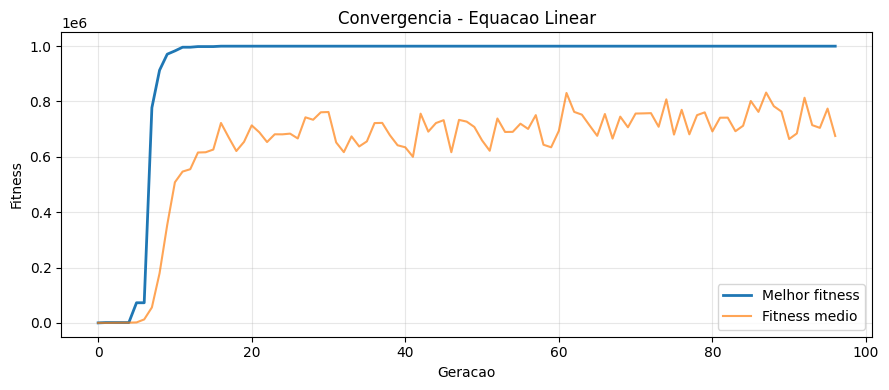

In [16]:
np.random.seed(42)
random.seed(42)

eq = EquacaoLinear(tamanho_populacao=100, taxa_mutacao=0.1)
inicio = time.perf_counter()
melhor_individuo_eq, melhor_fitness_eq, historico_eq = eq.evoluir(
    max_geracoes=1000, objetivo_fitness=1e6, paciencia=80, verbose=False
 )
tempo_eq = time.perf_counter() - inicio

x, y, z = melhor_individuo_eq
erro_eq = abs((x + y + z) - 3.0)

print("=== Desafio 1: Equacao Linear ===")
print(f"Melhor individuo: x={x:.4f}, y={y:.4f}, z={z:.4f}")
print(f"x + y + z = {x + y + z:.6f}")
print(f"Erro absoluto: {erro_eq:.8f}")
print(f"Melhor fitness: {melhor_fitness_eq:.6f}")
print(f"Tempo total: {tempo_eq:.4f} s")

plotar_convergencia(historico_eq, "Convergencia - Equacao Linear")

In [17]:
class Ackley(AlgoritmoGenetico):
    def __init__(self, tamanho_populacao, taxa_mutacao):
        super().__init__(tamanho_populacao, taxa_mutacao)
        self.dimensoes = 2

    def gerar_individuo(self):
        return np.random.uniform(-32.0, 32.0, self.dimensoes)

    def valor_ackley(self, individuo):
        x, y = individuo
        termo1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x ** 2 + y ** 2)))
        termo2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
        return termo1 + termo2 + np.e + 20

    def calcular_fitness(self, individuo):
        valor = self.valor_ackley(individuo)
        return 1.0 / (valor + 1e-6)

    def crossover(self, pai1, pai2):
        alpha = random.random()
        return alpha * pai1 + (1 - alpha) * pai2

    def mutacao(self, individuo):
        for i in range(self.dimensoes):
            if random.random() < self.taxa_mutacao:
                individuo[i] += np.random.normal(loc=0.0, scale=1.0)
        np.clip(individuo, -32.0, 32.0, out=individuo)

In [18]:
class CaixeiroViajante(AlgoritmoGenetico):
    def __init__(self, coordenadas_cidades, tamanho_populacao, taxa_mutacao):
        super().__init__(tamanho_populacao, taxa_mutacao)
        self.cidades = np.asarray(coordenadas_cidades)
        self.num_cidades = len(coordenadas_cidades)

    def gerar_individuo(self):
        individuo = np.arange(self.num_cidades)
        np.random.shuffle(individuo)
        return individuo

    def distancia_total(self, rota):
        coords = self.cidades[rota]
        proximo = np.roll(coords, -1, axis=0)
        distancias = np.linalg.norm(coords - proximo, axis=1)
        return float(np.sum(distancias))

    def calcular_fitness(self, individuo):
        return 1.0 / (self.distancia_total(individuo) + 1e-9)

    def crossover(self, pai1, pai2):
        n = self.num_cidades
        inicio, fim = sorted(random.sample(range(n), 2))
        filho = np.full(n, -1, dtype=int)
        filho[inicio:fim] = pai1[inicio:fim]

        genes_restantes = [gene for gene in pai2 if gene not in filho]
        pos_livres = [i for i, gene in enumerate(filho) if gene == -1]
        for pos, gene in zip(pos_livres, genes_restantes):
            filho[pos] = gene

        return filho

    def mutacao(self, individuo):
        if random.random() < self.taxa_mutacao:
            i, j = random.sample(range(self.num_cidades), 2)
            individuo[i], individuo[j] = individuo[j], individuo[i]


def plotar_rota_tsp(cidades, rota, titulo="Rota TSP"):
    cidades_ordenadas = cidades[rota]
    cidades_ordenadas = np.vstack([cidades_ordenadas, cidades_ordenadas[0]])

    plt.figure(figsize=(7, 7))
    plt.plot(cidades_ordenadas[:, 0], cidades_ordenadas[:, 1], "-o", markersize=4)
    plt.title(titulo)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
cidades_tsp = np.array([
    [2.0, 99.0], [4.0, 50.0], [7.0, 64.0], [13.0, 40.0], [18.0, 54.0],
    [18.0, 40.0], [22.0, 60.0], [24.0, 42.0], [25.0, 62.0], [25.0, 38.0],
    [37.0, 84.0], [41.0, 94.0], [41.0, 26.0], [44.0, 35.0], [45.0, 21.0],
    [54.0, 67.0], [54.0, 62.0], [58.0, 69.0], [58.0, 35.0], [62.0, 32.0],
    [64.0, 60.0], [68.0, 58.0], [71.0, 71.0], [71.0, 44.0], [74.0, 78.0],
    [82.0, 7.0],  [83.0, 69.0], [83.0, 46.0], [87.0, 76.0], [91.0, 38.0]
], dtype=float)

=== Desafio 2: Funcao de Ackley ===
Melhor individuo: x=-0.000000, y=0.000000
Ackley(x, y): 0.00000008
Melhor fitness: 922989.219504
Tempo total: 1.5863 s


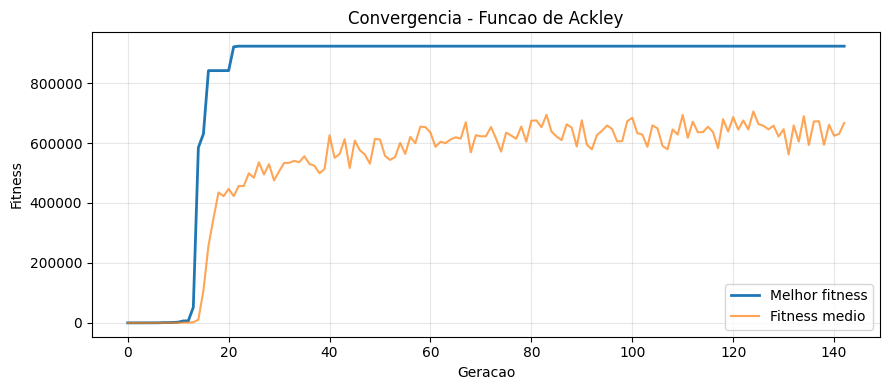

In [20]:
np.random.seed(42)
random.seed(42)

ack = Ackley(tamanho_populacao=150, taxa_mutacao=0.15)
inicio = time.perf_counter()
melhor_individuo_ack, melhor_fitness_ack, historico_ack = ack.evoluir(
    max_geracoes=600, paciencia=120, verbose=False
)
tempo_ack = time.perf_counter() - inicio

valor_ackley = ack.valor_ackley(melhor_individuo_ack)

print("=== Desafio 2: Funcao de Ackley ===")
print(f"Melhor individuo: x={melhor_individuo_ack[0]:.6f}, y={melhor_individuo_ack[1]:.6f}")
print(f"Ackley(x, y): {valor_ackley:.8f}")
print(f"Melhor fitness: {melhor_fitness_ack:.6f}")
print(f"Tempo total: {tempo_ack:.4f} s")

plotar_convergencia(historico_ack, "Convergencia - Funcao de Ackley")

=== Desafio 3: Caixeiro Viajante ===
Melhor distancia total: 461.7231
Melhor fitness: 0.00216580
Tempo total: 65.2479 s


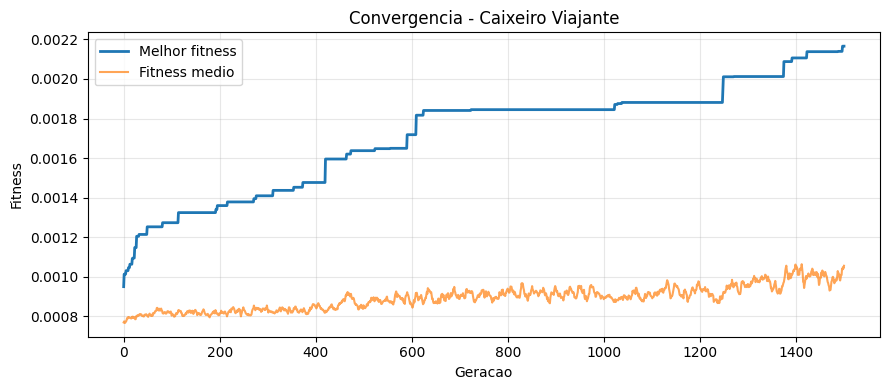

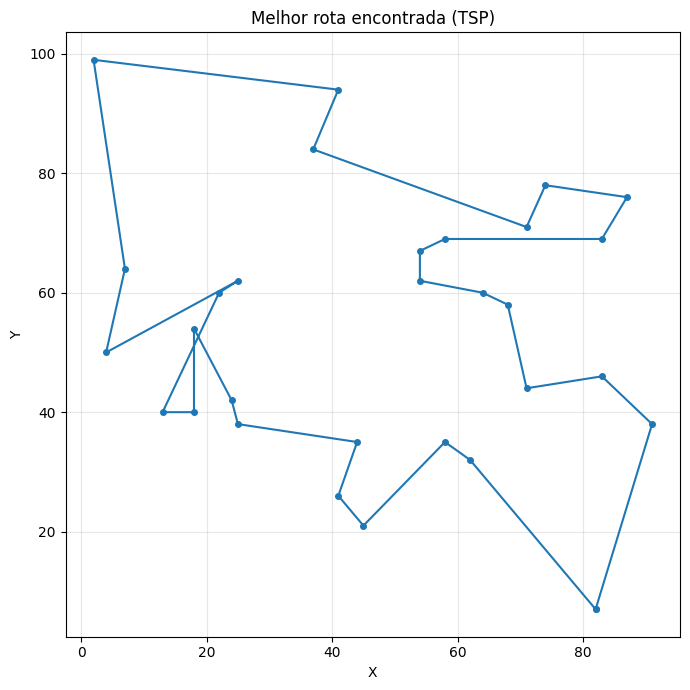

In [22]:
np.random.seed(42)
random.seed(42)

tsp = CaixeiroViajante(cidades_tsp, tamanho_populacao=220, taxa_mutacao=0.2)
inicio = time.perf_counter()
melhor_rota, melhor_fitness_tsp, historico_tsp = tsp.evoluir(
    max_geracoes=1500, paciencia=300, verbose=False
)
tempo_tsp = time.perf_counter() - inicio

melhor_distancia = tsp.distancia_total(melhor_rota)

print("=== Desafio 3: Caixeiro Viajante ===")
print(f"Melhor distancia total: {melhor_distancia:.4f}")
print(f"Melhor fitness: {melhor_fitness_tsp:.8f}")
print(f"Tempo total: {tempo_tsp:.4f} s")

plotar_convergencia(historico_tsp, "Convergencia - Caixeiro Viajante")
plotar_rota_tsp(cidades_tsp, melhor_rota, titulo="Melhor rota encontrada (TSP)")